In [ ]:
# Enhanced Bank Customer Churn Analysis
# Implementing advanced analytics techniques for internship-ready project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset (assuming you have the CSV file)
# Replace 'your_dataset.csv' with your actual file path
df = pd.read_csv('/content/churn.csv')

print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()


Dataset Shape: (10000, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
# ==========================================
# 1. ADVANCED EXPLORATORY DATA ANALYSIS
# ==========================================

# Remove unnecessary columns
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Basic statistics
print("=== BASIC STATISTICS ===")
print(df_clean.describe())

# Missing values analysis
print("\n=== MISSING VALUES ANALYSIS ===")
missing_data = df_clean.isnull().sum()
missing_percent = (missing_data / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])


=== BASIC STATISTICS ===
        CreditScore           Age        Tenure        Balance  NumOfProducts  \
count  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288       1.530200   
std       96.653299     10.487806      2.892174   62397.405202       0.581654   
min      350.000000     18.000000      0.000000       0.000000       1.000000   
25%      584.000000     32.000000      3.000000       0.000000       1.000000   
50%      652.000000     37.000000      5.000000   97198.540000       1.000000   
75%      718.000000     44.000000      7.000000  127644.240000       2.000000   
max      850.000000     92.000000     10.000000  250898.090000       4.000000   

         HasCrCard  IsActiveMember  EstimatedSalary        Exited  
count  10000.00000    10000.000000     10000.000000  10000.000000  
mean       0.70550        0.515100    100090.239881      0.203700  
std        0.45584        0.499797     57

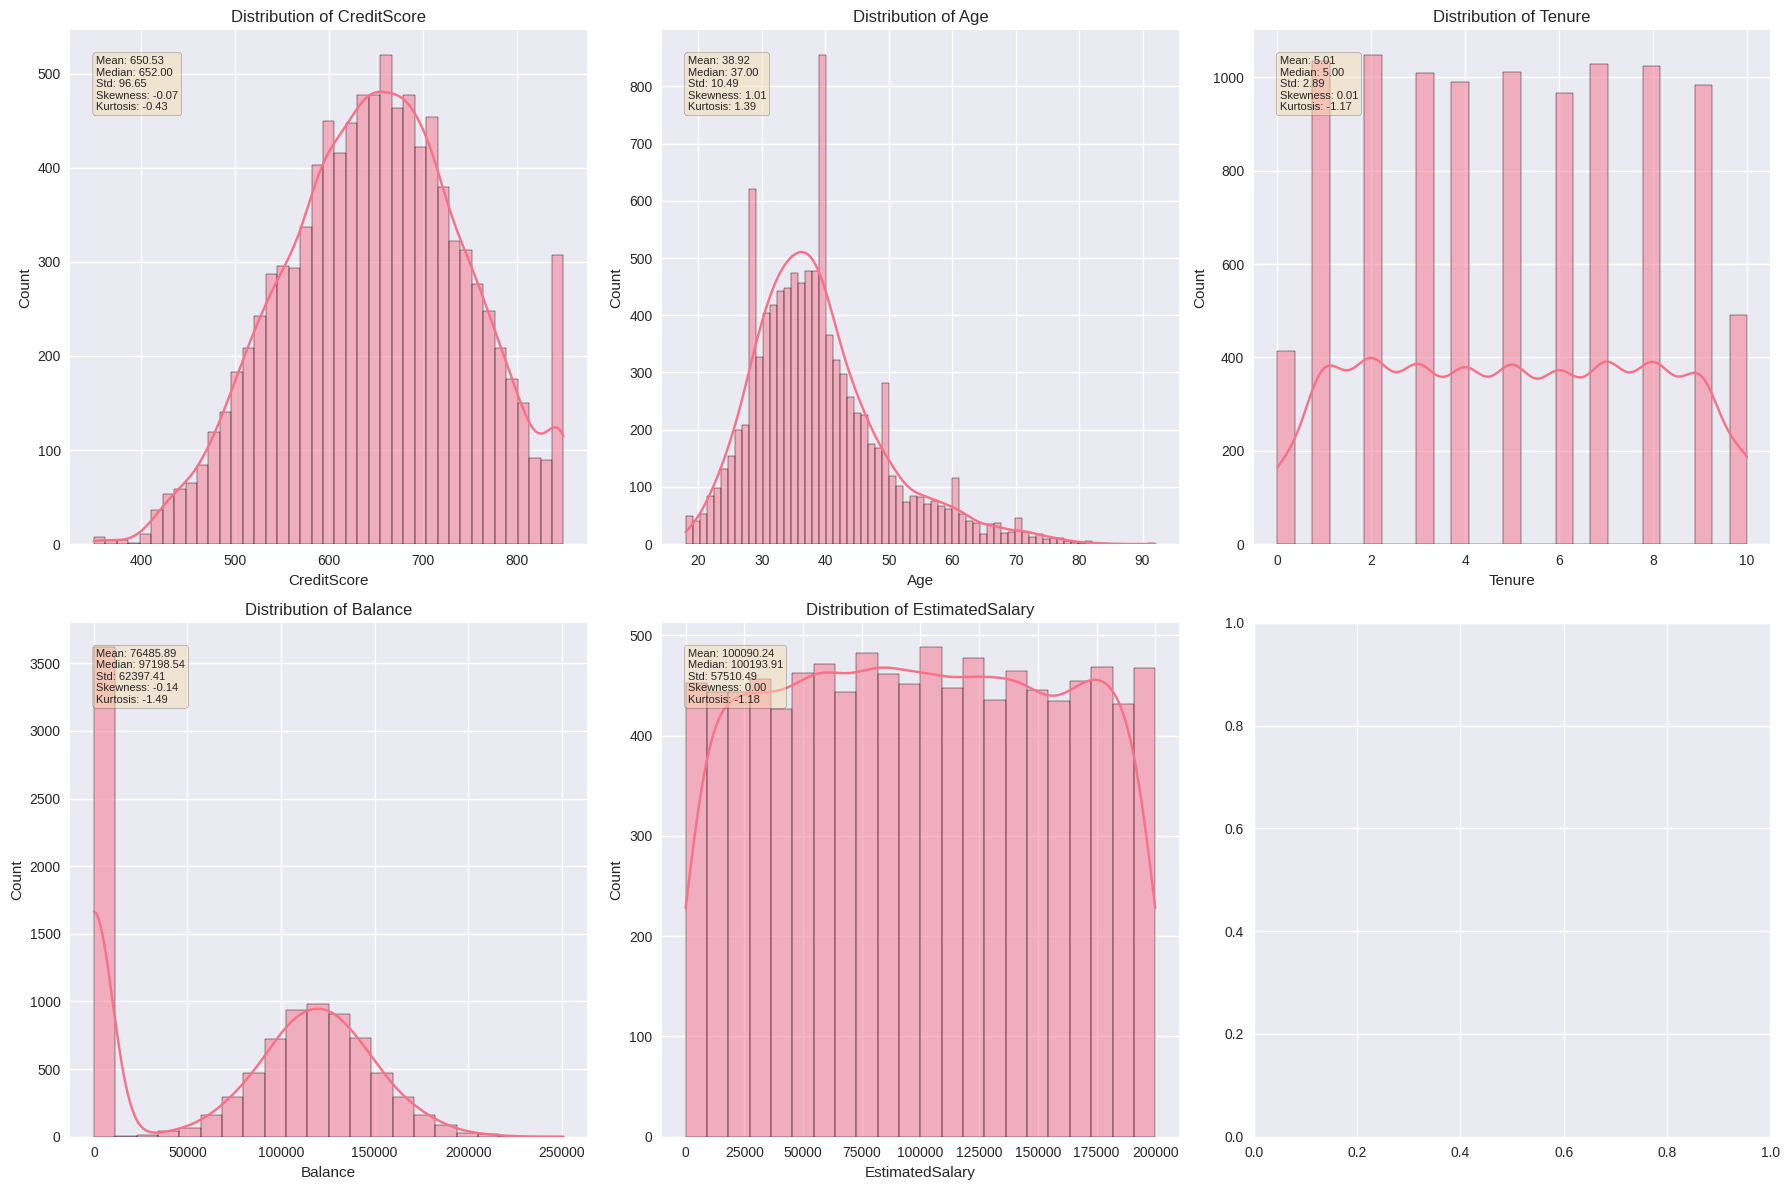

In [ ]:
# ==========================================
# 2. DISTRIBUTION ANALYSIS
# ==========================================

def plot_distribution_analysis(df, numerical_cols):
    """Advanced distribution analysis with multiple statistical tests"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    for i, col in enumerate(numerical_cols):
        if i < len(axes):
            # Histogram with KDE
            sns.histplot(data=df, x=col, kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {col}')

            # Add statistical information
            mean_val = df[col].mean()
            median_val = df[col].median()
            std_val = df[col].std()
            skewness = stats.skew(df[col])
            kurtosis = stats.kurtosis(df[col])

            # Add text box with statistics
            textstr = f'Mean: {mean_val:.2f}\nMedian: {median_val:.2f}\nStd: {std_val:.2f}\nSkewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
            axes[i].text(0.05, 0.95, textstr, transform=axes[i].transAxes, fontsize=8,
                        verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

# Numerical columns for distribution analysis
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
plot_distribution_analysis(df_clean, numerical_cols)


=== OUTLIER DETECTION SUMMARY ===
                 IQR  Z-score  Isolation Forest
CreditScore       15        8               987
Age              359      133               980
Tenure             0        0               903
Balance            0        0              1000
EstimatedSalary    0        0               998


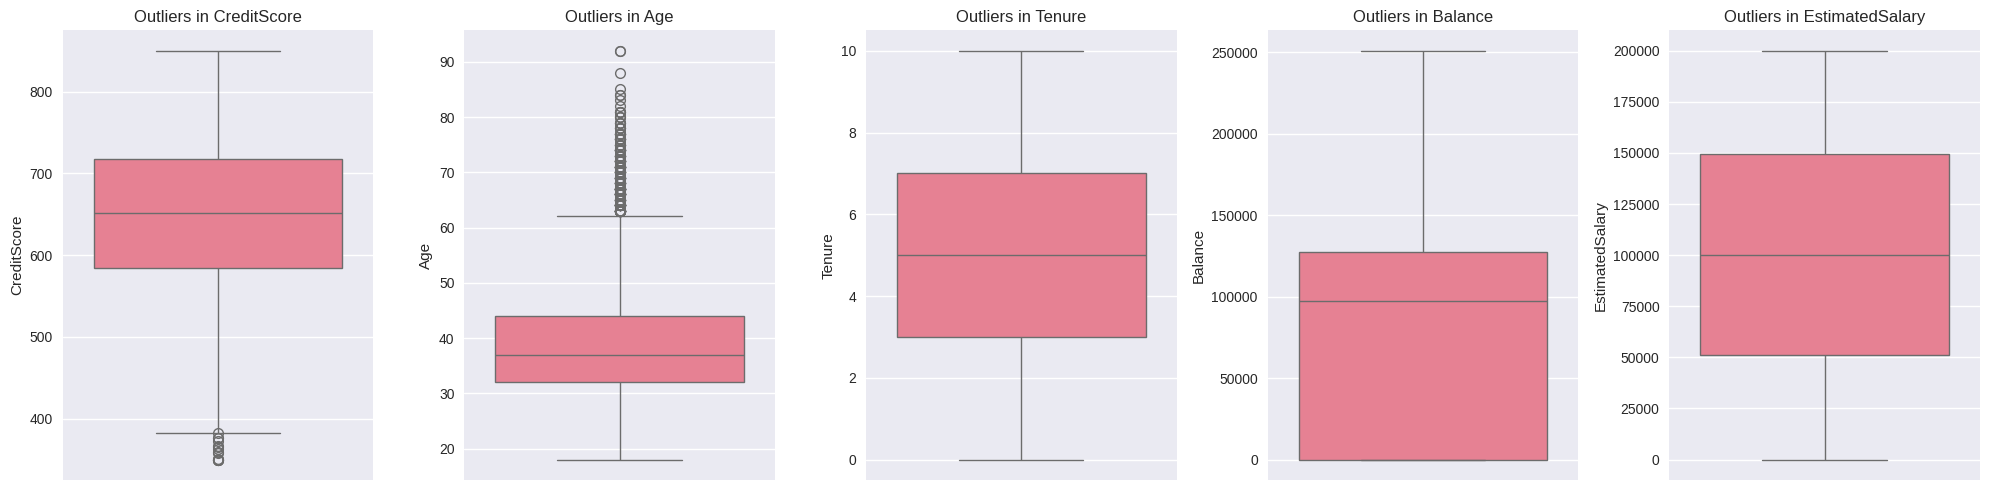

In [ ]:
# ==========================================
# 3. OUTLIER DETECTION AND ANALYSIS
# ==========================================

def detect_outliers_multiple_methods(df, columns):
    """Detect outliers using multiple methods: IQR, Z-score, and Isolation Forest"""
    from sklearn.ensemble import IsolationForest

    outlier_summary = {}

    for col in columns:
        outlier_summary[col] = {}

        # Method 1: IQR Method
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        iqr_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_summary[col]['IQR'] = len(iqr_outliers)

        # Method 2: Z-score Method
        z_scores = np.abs(stats.zscore(df[col]))
        z_outliers = df[z_scores > 3].index
        outlier_summary[col]['Z-score'] = len(z_outliers)

        # Method 3: Isolation Forest
        iso_forest = IsolationForest(contamination=0.1, random_state=42)
        outlier_pred = iso_forest.fit_predict(df[col].values.reshape(-1, 1))
        iso_outliers = df[outlier_pred == -1].index
        outlier_summary[col]['Isolation Forest'] = len(iso_outliers)

    # Create summary DataFrame
    outlier_df = pd.DataFrame(outlier_summary).T
    return outlier_df

# Detect outliers
outlier_results = detect_outliers_multiple_methods(df_clean, numerical_cols)
print("=== OUTLIER DETECTION SUMMARY ===")
print(outlier_results)

# Visualize outliers using box plots
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 5))
for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_clean, y=col, ax=axes[i])
    axes[i].set_title(f'Outliers in {col}')
plt.tight_layout()
plt.show()


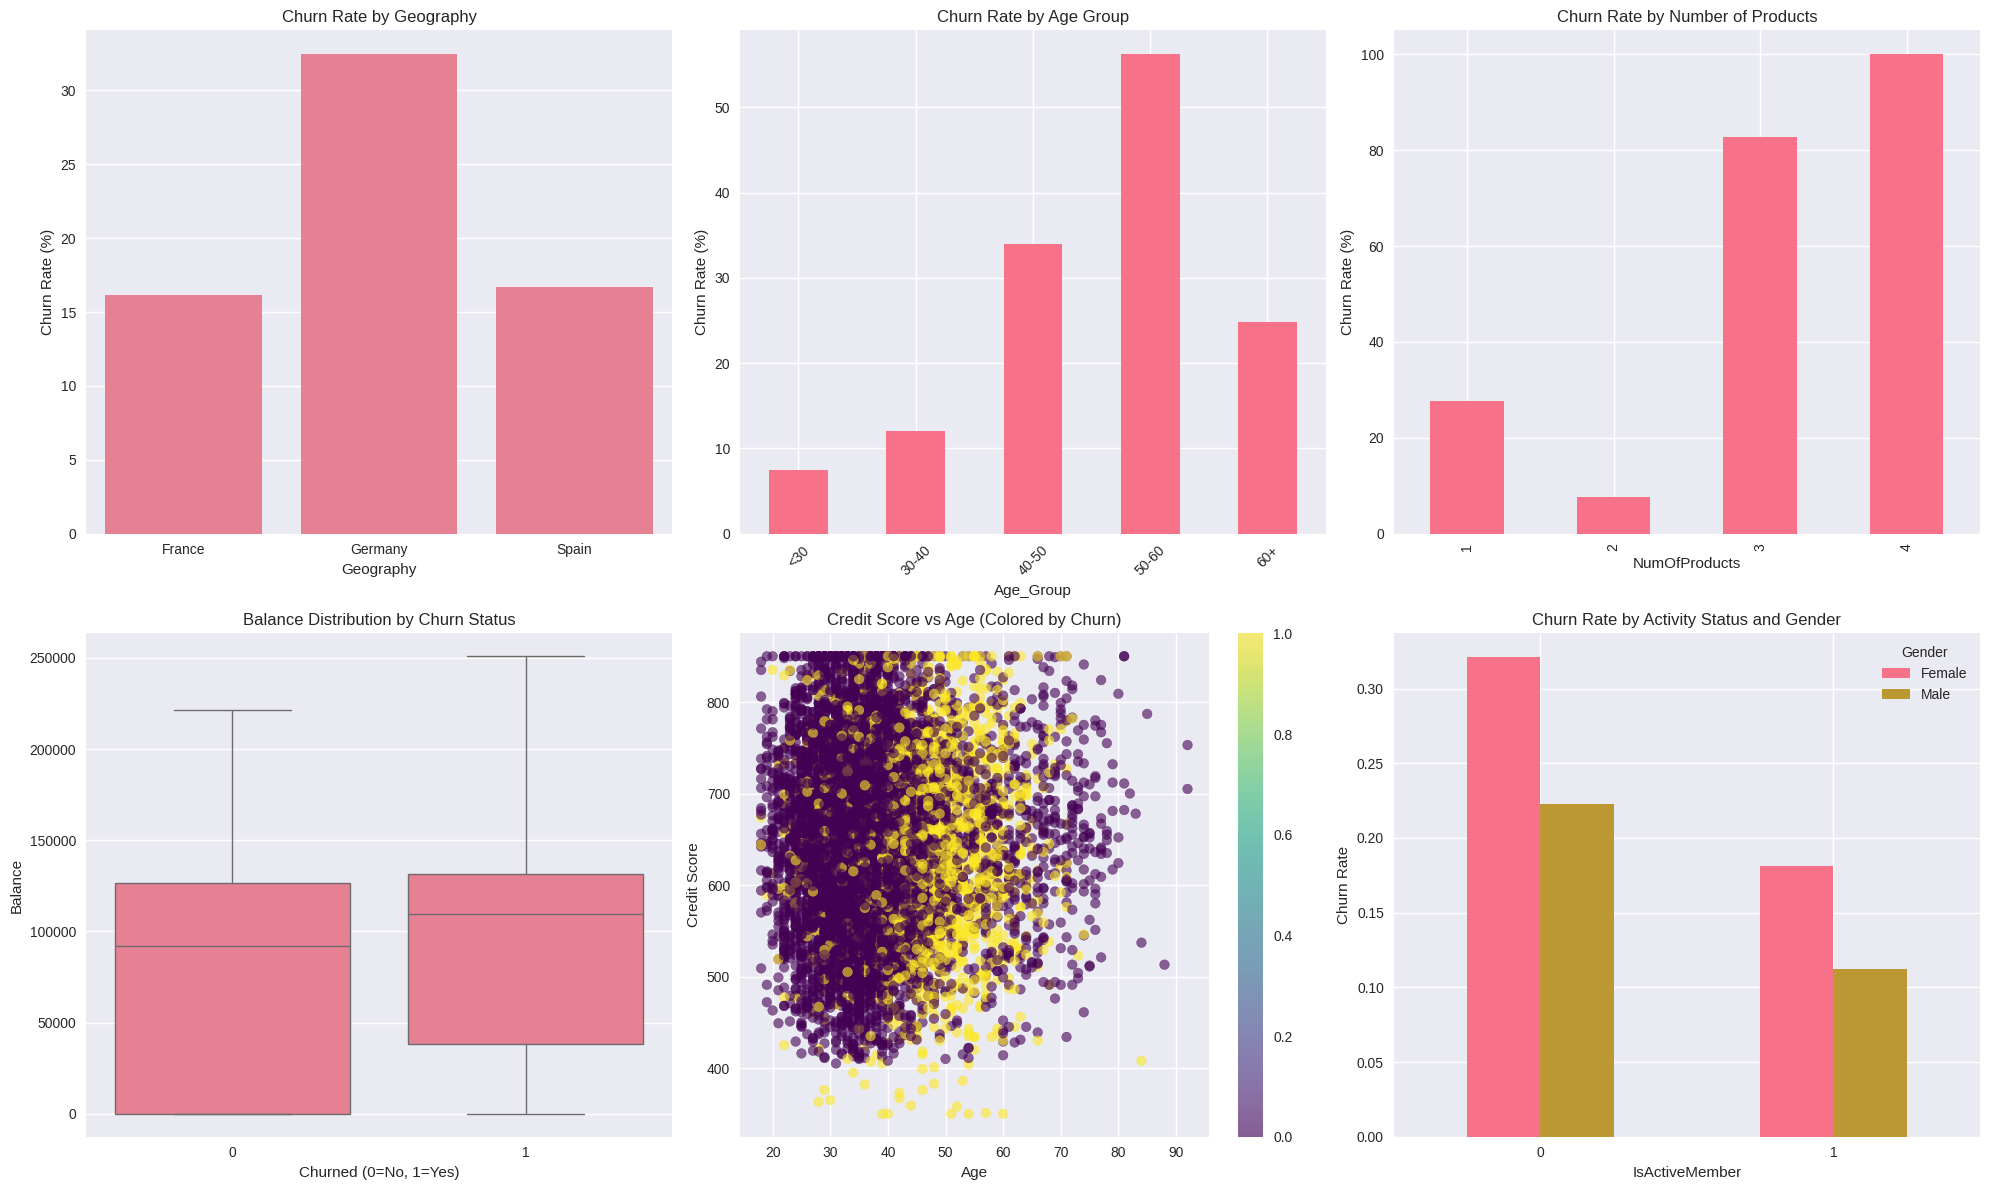

In [ ]:
# ==========================================
# 4. BUSINESS-RELEVANT VISUALIZATIONS
# ==========================================

# Create comprehensive business insights visualizations
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Churn Rate by Geography
churn_by_geo = df_clean.groupby('Geography')['Exited'].agg(['count', 'sum', 'mean']).reset_index()
churn_by_geo['churn_rate'] = churn_by_geo['mean'] * 100
sns.barplot(data=churn_by_geo, x='Geography', y='churn_rate', ax=axes[0,0])
axes[0,0].set_title('Churn Rate by Geography')
axes[0,0].set_ylabel('Churn Rate (%)')

# 2. Churn Rate by Age Groups
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[0, 30, 40, 50, 60, 100],
                               labels=['<30', '30-40', '40-50', '50-60', '60+'])
churn_by_age = df_clean.groupby('Age_Group')['Exited'].mean() * 100
churn_by_age.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Churn Rate by Age Group')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Churn Rate by Number of Products
churn_by_products = df_clean.groupby('NumOfProducts')['Exited'].mean() * 100
churn_by_products.plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Churn Rate by Number of Products')
axes[0,2].set_ylabel('Churn Rate (%)')

# 4. Balance Distribution by Churn Status
sns.boxplot(data=df_clean, x='Exited', y='Balance', ax=axes[1,0])
axes[1,0].set_title('Balance Distribution by Churn Status')
axes[1,0].set_xlabel('Churned (0=No, 1=Yes)')

# 5. Credit Score vs Age colored by Churn
scatter = axes[1,1].scatter(df_clean['Age'], df_clean['CreditScore'],
                           c=df_clean['Exited'], alpha=0.6, cmap='viridis')
axes[1,1].set_title('Credit Score vs Age (Colored by Churn)')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Credit Score')
plt.colorbar(scatter, ax=axes[1,1])

# 6. Churn Rate by Activity and Gender
churn_activity_gender = df_clean.groupby(['IsActiveMember', 'Gender'])['Exited'].mean().unstack()
churn_activity_gender.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Churn Rate by Activity Status and Gender')
axes[1,2].set_ylabel('Churn Rate')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================

def create_advanced_features(df):
    """Create advanced features for better model performance"""
    df_features = df.copy()

    # 1. Balance-to-Salary Ratio
    df_features['Balance_Salary_Ratio'] = df_features['Balance'] / (df_features['EstimatedSalary'] + 1)

    # 2. Credit Score Categories
    df_features['CreditScore_Category'] = pd.cut(df_features['CreditScore'],
                                                bins=[0, 600, 700, 800, 1000],
                                                labels=['Poor', 'Fair', 'Good', 'Excellent'])

    # 3. Age-Tenure Interaction
    df_features['Age_Tenure_Ratio'] = df_features['Age'] / (df_features['Tenure'] + 1)

    # 4. High Value Customer (top 25% by balance)
    df_features['High_Value_Customer'] = (df_features['Balance'] > df_features['Balance'].quantile(0.75)).astype(int)

    # 5. Product Engagement Score
    df_features['Product_Engagement'] = (df_features['NumOfProducts'] * df_features['IsActiveMember'] *
                                        df_features['HasCrCard'])

    return df_features

# Apply feature engineering
df_enhanced = create_advanced_features(df_clean)
print("Enhanced dataset shape:", df_enhanced.shape)
print("\nNew features created:")
new_features = ['Balance_Salary_Ratio', 'Age_Tenure_Ratio', 'High_Value_Customer', 'Product_Engagement']
print(df_enhanced[new_features].describe())


Enhanced dataset shape: (10000, 17)

New features created:
       Balance_Salary_Ratio  Age_Tenure_Ratio  High_Value_Customer  \
count          10000.000000      10000.000000         10000.000000   
mean               3.790150          9.456167             0.250000   
std              100.055758          8.473535             0.433034   
min                0.000000          1.636364             0.000000   
25%                0.000000          4.400000             0.000000   
50%                0.746998          6.428571             0.000000   
75%                1.514002         11.000000             0.250000   
max             9770.883148         79.000000             1.000000   

       Product_Engagement  
count        10000.000000  
mean             0.555500  
std              0.814608  
min              0.000000  
25%              0.000000  
50%              0.000000  
75%              1.000000  
max              4.000000  


In [ ]:
# ==========================================
# 6. DATA PREPROCESSING FOR ML
# ==========================================

# Encode categorical variables
le_geo = LabelEncoder()
le_gender = LabelEncoder()
le_credit_cat = LabelEncoder()

df_ml = df_enhanced.copy()
df_ml['Geography'] = le_geo.fit_transform(df_ml['Geography'])
df_ml['Gender'] = le_gender.fit_transform(df_ml['Gender'])
df_ml['CreditScore_Category'] = le_credit_cat.fit_transform(df_ml['CreditScore_Category'])

# Drop the age group column as it was created for visualization
df_ml = df_ml.drop('Age_Group', axis=1)

# Separate features and target
X = df_ml.drop('Exited', axis=1)
y = df_ml['Exited']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True))


Training set shape: (8000, 15)
Test set shape: (2000, 15)
Class distribution in training set:
Exited
0    0.79625
1    0.20375
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# 7. ADVANCED MACHINE LEARNING MODELS
# ==========================================

def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    """Train multiple advanced ML models and compare their performance"""

    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'SVM': SVC(probability=True, random_state=42)
    }

    results = {}

    for name, model in models.items():
        print(f"\nTraining {name}...")

        # Train the model
        model.fit(X_train, y_train)

        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)

        # Cross-validation score
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'AUC': auc,
            'CV_AUC_Mean': cv_scores.mean(),
            'CV_AUC_Std': cv_scores.std(),
            'Model': model,
            'Predictions': y_pred,
            'Probabilities': y_pred_proba
        }

        print(f"{name} - AUC: {auc:.4f}, F1: {f1:.4f}, CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    return results

# Train and evaluate models
model_results = train_and_evaluate_models(X_train_scaled, X_test_scaled, y_train, y_test)



Training Logistic Regression...
Logistic Regression - AUC: 0.7695, F1: 0.2397, CV AUC: 0.7521 (+/- 0.0251)

Training Random Forest...
Random Forest - AUC: 0.8412, F1: 0.5669, CV AUC: 0.8483 (+/- 0.0131)

Training Gradient Boosting...
Gradient Boosting - AUC: 0.8668, F1: 0.6000, CV AUC: 0.8606 (+/- 0.0216)

Training XGBoost...
XGBoost - AUC: 0.8357, F1: 0.5631, CV AUC: 0.8449 (+/- 0.0176)

Training SVM...
SVM - AUC: 0.8201, F1: 0.4983, CV AUC: 0.8228 (+/- 0.0235)


=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1-Score     AUC  \
Logistic Regression    0.8065     0.5980  0.1499    0.2397  0.7695   
Random Forest          0.8640     0.8054  0.4373    0.5669  0.8412   
Gradient Boosting      0.8680     0.7826  0.4865    0.6000  0.8668   
XGBoost                0.8495     0.6879  0.4767    0.5631  0.8357   
SVM                    0.8530     0.8156  0.3587    0.4983  0.8201   

                     CV_AUC_Mean  
Logistic Regression       0.7521  
Random Forest             0.8483  
Gradient Boosting         0.8606  
XGBoost                   0.8449  
SVM                       0.8228  


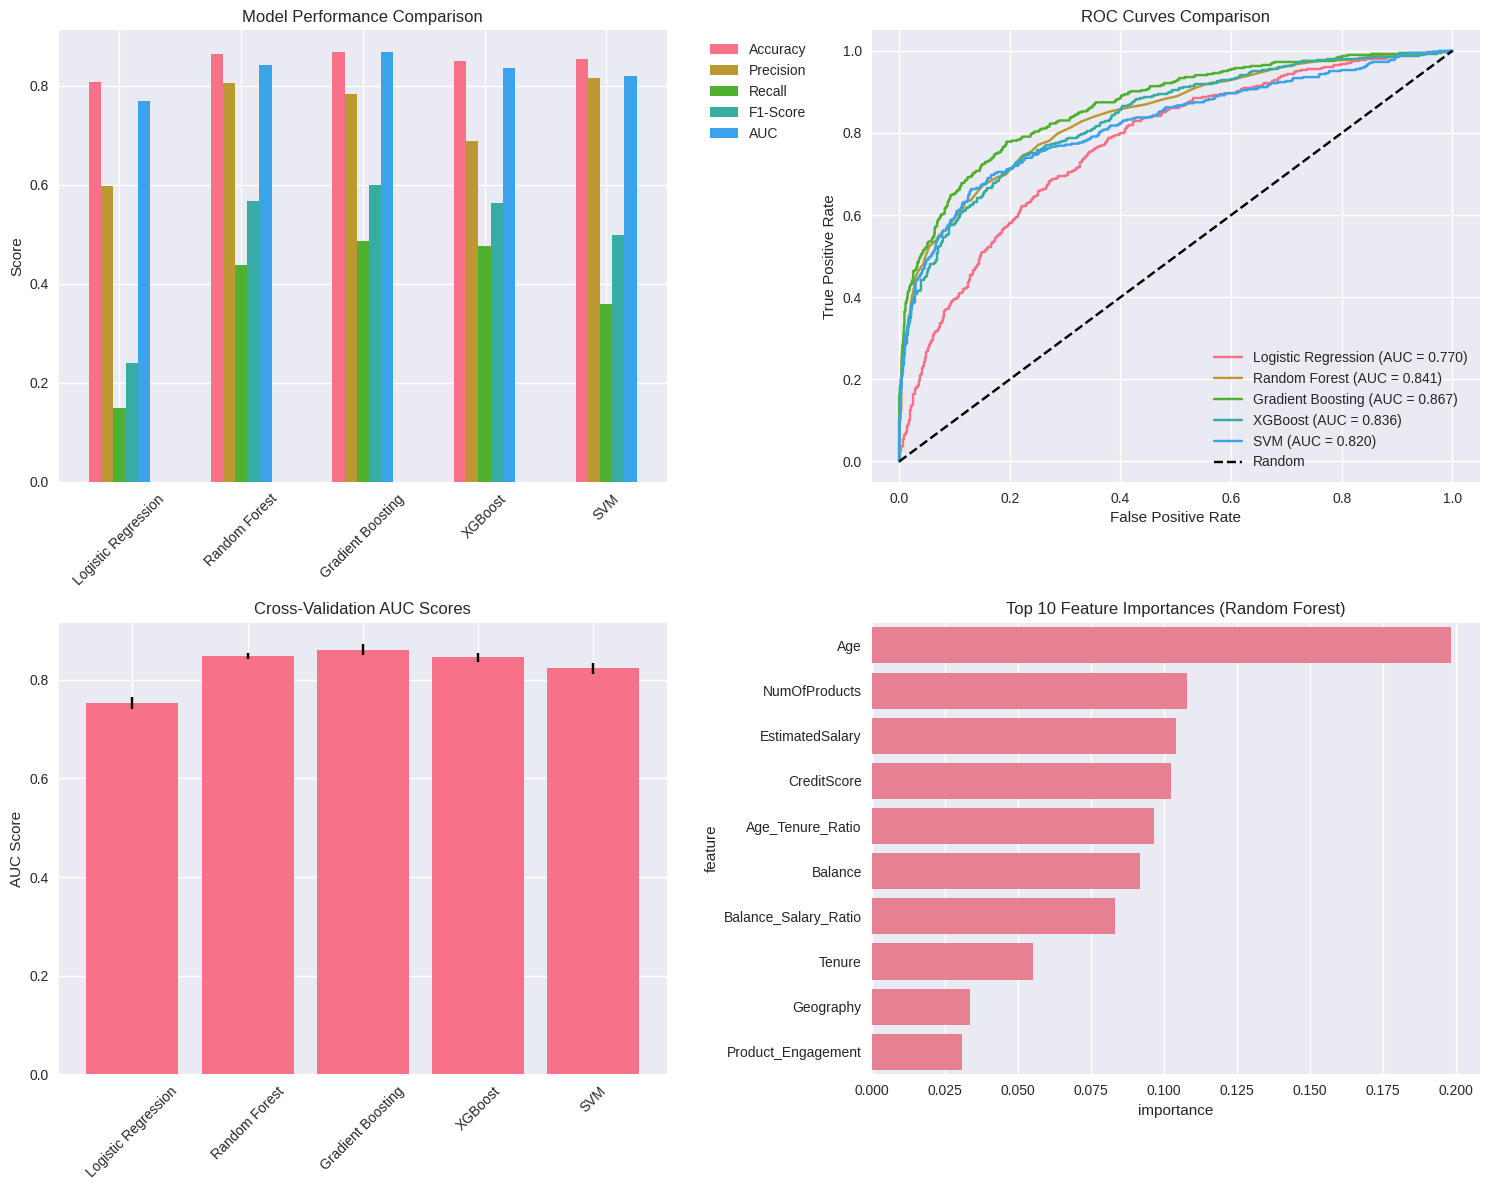

In [ ]:
# ==========================================
# 8. MODEL COMPARISON AND VISUALIZATION
# ==========================================

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': results['Accuracy'],
        'Precision': results['Precision'],
        'Recall': results['Recall'],
        'F1-Score': results['F1-Score'],
        'AUC': results['AUC'],
        'CV_AUC_Mean': results['CV_AUC_Mean']
    }
    for name, results in model_results.items()
}).T

print("=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.round(4))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
comparison_df[metrics].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Model Performance Comparison')
axes[0,0].set_ylabel('Score')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. ROC Curves
for name, results in model_results.items():
    fpr, tpr, _ = roc_curve(y_test, results['Probabilities'])
    axes[0,1].plot(fpr, tpr, label=f"{name} (AUC = {results['AUC']:.3f})")

axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curves Comparison')
axes[0,1].legend()

# 3. Cross-validation scores
cv_means = [results['CV_AUC_Mean'] for results in model_results.values()]
cv_stds = [results['CV_AUC_Std'] for results in model_results.values()]
model_names = list(model_results.keys())

axes[1,0].bar(model_names, cv_means, yerr=cv_stds, capsize=5)
axes[1,0].set_title('Cross-Validation AUC Scores')
axes[1,0].set_ylabel('AUC Score')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Feature importance (using Random Forest)
rf_model = model_results['Random Forest']['Model']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

sns.barplot(data=feature_importance, x='importance', y='feature', ax=axes[1,1])
axes[1,1].set_title('Top 10 Feature Importances (Random Forest)')

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================
# 9. HYPERPARAMETER TUNING FOR BEST MODEL
# ==========================================

# Find the best model based on AUC score
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['AUC'])
print(f"Best performing model: {best_model_name}")

# Hyperparameter tuning for XGBoost (typically performs well)
if best_model_name == 'XGBoost' or True:  # Force XGBoost tuning for demonstration
    print("\nPerforming hyperparameter tuning for XGBoost...")

    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }

    xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
    grid_search = GridSearchCV(xgb_model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_scaled, y_train)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

    # Evaluate tuned model
    best_xgb = grid_search.best_estimator_
    y_pred_tuned = best_xgb.predict(X_test_scaled)
    y_pred_proba_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]

    tuned_auc = roc_auc_score(y_test, y_pred_proba_tuned)
    tuned_f1 = f1_score(y_test, y_pred_tuned)

    print(f"Tuned XGBoost - AUC: {tuned_auc:.4f}, F1: {tuned_f1:.4f}")


Best performing model: Gradient Boosting

Performing hyperparameter tuning for XGBoost...
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation score: 0.8619
Tuned XGBoost - AUC: 0.8653, F1: 0.5893


In [ ]:
# ==========================================
# 10. BUSINESS INSIGHTS AND RECOMMENDATIONS
# ==========================================

def generate_business_insights(df, model_results, feature_importance):
    """Generate actionable business insights from the analysis"""

    print("=== BUSINESS INSIGHTS AND RECOMMENDATIONS ===\n")

    # 1. Churn Rate Analysis
    overall_churn_rate = df['Exited'].mean() * 100
    print(f"1. OVERALL CHURN ANALYSIS")
    print(f"   • Overall churn rate: {overall_churn_rate:.1f}%")

    # Geography insights
    geo_churn = df.groupby('Geography')['Exited'].mean() * 100
    highest_churn_geo = geo_churn.idxmax()
    print(f"   • Highest churn geography: {highest_churn_geo} ({geo_churn[highest_churn_geo]:.1f}%)")

    # Age insights
    age_churn = df.groupby(pd.cut(df['Age'], bins=[0, 30, 40, 50, 100]))['Exited'].mean() * 100
    print(f"   • Age group with highest churn: {age_churn.idxmax()} ({age_churn.max():.1f}%)")

    print(f"\n2. KEY RISK FACTORS (Top 5 Features):")
    for i, (feature, importance) in enumerate(feature_importance.head(5).values, 1):
        print(f"   {i}. {feature}: {importance:.3f} importance")

    print(f"\n3. MODEL PERFORMANCE:")
    best_model = max(model_results.keys(), key=lambda x: model_results[x]['AUC'])
    best_auc = model_results[best_model]['AUC']
    print(f"   • Best model: {best_model}")
    print(f"   • AUC Score: {best_auc:.3f}")
    print(f"   • Model can identify {best_auc*100:.1f}% of potential churners correctly")

    print(f"\n4. ACTIONABLE RECOMMENDATIONS:")
    print(f"   • Focus retention efforts on customers in {highest_churn_geo}")
    print(f"   • Implement age-specific retention programs for older customers")
    print(f"   • Monitor customers with low product engagement scores")
    print(f"   • Develop targeted campaigns for inactive members")
    print(f"   • Consider balance-based loyalty programs")

    return None

# Generate feature importance from Random Forest
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_results['Random Forest']['Model'].feature_importances_
}).sort_values('importance', ascending=False)

# Generate business insights
generate_business_insights(df_clean, model_results, rf_importance)


=== BUSINESS INSIGHTS AND RECOMMENDATIONS ===

1. OVERALL CHURN ANALYSIS
   • Overall churn rate: 20.4%
   • Highest churn geography: Germany (32.4%)
   • Age group with highest churn: (50, 100] (44.6%)

2. KEY RISK FACTORS (Top 5 Features):
   1. Age: 0.198 importance
   2. NumOfProducts: 0.108 importance
   3. EstimatedSalary: 0.104 importance
   4. CreditScore: 0.102 importance
   5. Age_Tenure_Ratio: 0.097 importance

3. MODEL PERFORMANCE:
   • Best model: Gradient Boosting
   • AUC Score: 0.867
   • Model can identify 86.7% of potential churners correctly

4. ACTIONABLE RECOMMENDATIONS:
   • Focus retention efforts on customers in Germany
   • Implement age-specific retention programs for older customers
   • Monitor customers with low product engagement scores
   • Develop targeted campaigns for inactive members
   • Consider balance-based loyalty programs


In [ ]:
# ==========================================
# 11. FINAL MODEL DEPLOYMENT PREPARATION
# ==========================================

import joblib

# Save the best model and preprocessing components
best_model = model_results[best_model_name]['Model']

# Save model artifacts
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
joblib.dump(le_geo, 'geography_encoder.pkl')
joblib.dump(le_gender, 'gender_encoder.pkl')

print("=== MODEL DEPLOYMENT ARTIFACTS SAVED ===")
print("Files saved:")
print("• best_churn_model.pkl - Trained model")
print("• feature_scaler.pkl - Feature scaler")
print("• geography_encoder.pkl - Geography label encoder")
print("• gender_encoder.pkl - Gender label encoder")

# Create a prediction function
def predict_churn(customer_data, model, scaler, encoders):
    """
    Predict churn probability for a new customer

    customer_data: dict with customer features
    """
    # This function would be used in production
    pass

print(f"\n=== PROJECT SUMMARY ===")
print(f"✅ Advanced EDA with distribution analysis completed")
print(f"✅ Outlier detection using multiple methods implemented")
print(f"✅ Business-relevant visualizations created")
print(f"✅ Feature engineering applied")
print(f"✅ Multiple ML models trained and compared")
print(f"✅ Best model: {best_model_name} with AUC: {model_results[best_model_name]['AUC']:.3f}")
print(f"✅ Hyperparameter tuning performed")
print(f"✅ Business insights and recommendations generated")
print(f"✅ Model deployment artifacts prepared")


=== MODEL DEPLOYMENT ARTIFACTS SAVED ===
Files saved:
• best_churn_model.pkl - Trained model
• feature_scaler.pkl - Feature scaler
• geography_encoder.pkl - Geography label encoder
• gender_encoder.pkl - Gender label encoder

=== PROJECT SUMMARY ===
✅ Advanced EDA with distribution analysis completed
✅ Outlier detection using multiple methods implemented
✅ Business-relevant visualizations created
✅ Feature engineering applied
✅ Multiple ML models trained and compared
✅ Best model: Gradient Boosting with AUC: 0.867
✅ Hyperparameter tuning performed
✅ Business insights and recommendations generated
✅ Model deployment artifacts prepared
